<a href="https://colab.research.google.com/github/zilmara-rodrigues/deep-learning-aulas-resolvidas/blob/main/aprend_profundo_16_recurrent_neural_networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Redes Neurais Recorrentes

As Redes Neurais Recorrentes são arquiteturas desenvolvidas para o processamento de dados sequenciais. Diferente das redes tradicionais, que consideram as entradas independentes, estas redes possuem conexões que transmitem informações ao longo do tempo.

Essa característica possibilita manter uma memória de informações passadas por meio de um estado oculto, que funciona como um resumo das informações anteriores.

### Formulação

A formulação matemática básica de uma célula recorrente calcula o estado oculto e a respectiva saída por meio de transformações lineares e funções de ativação não lineares.

As equações principais para cada instante de tempo são descritas abaixo:

$$h_t = \tanh(W_{ih} x_t + b_{ih} + W_{hh} h_{t-1} + b_{hh})$$

$$y_t = W_{ho} h_t + b_{ho}$$

Definição de cada variável:
* $x_t$ representa o vetor de entrada no instante de tempo $t$, com dimensão de características.
* $h_t$ representa o estado oculto no instante de tempo $t$, atuando como a memória da rede.
* $W_{ih}$ e $W_{hh}$ representam as matrizes de pesos que conectam a entrada e o estado oculto anterior ao estado atual.
* $b_{ih}$ e $b_{hh}$ representam os vetores de viés para as transformações do estado oculto.
* $y_t$ representa a saída da rede no instante de tempo $t$.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Definindo sementes para reprodutibilidade
torch.manual_seed(42)
np.random.seed(42)

# Configuração do dispositivo de processamento
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo em uso:", device)

Dispositivo em uso: cuda


## Processamento de Sequências

Uma rede recorrente recebe uma sequência de dados e propaga a informação ao longo dos instantes de tempo. Vamos ilustrar essa dinâmica implementando uma célula básica, depois uma estrutura que realiza o loop sobre a sequência completa de tempo e finalmente comparando com a implementação nativa do PyTorch.

In [ ]:
class BasicRNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.input_to_hidden = nn.Linear(input_size, hidden_size)
        self.hidden_to_hidden = nn.Linear(hidden_size, hidden_size, bias=False)
        self.activation = nn.Tanh()

    def forward(self, x, h_prev):
        # x: [batch_size, input_size]
        # h_prev: [batch_size, hidden_size]
        return self.activation(self.input_to_hidden(x) + self.hidden_to_hidden(h_prev))

In [ ]:
class BasicRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = BasicRNNCell(input_size, hidden_size)

    def forward(self, x):
        # x: [batch_size, sequence_length, input_size]
        batch_size = x.size(0)
        sequence_length = x.size(1)

        h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        outputs = []

        for t in range(sequence_length):
            x_t = x[:, t, :]
            h = self.cell(x_t, h)
            outputs.append(h.unsqueeze(1))

        return torch.cat(outputs, dim=1), h

In [ ]:
batch_size = 3
sequence_length = 8
input_size = 4
hidden_size = 5

x_dummy = torch.randn(batch_size, sequence_length, input_size)
model_custom = BasicRNN(input_size, hidden_size)
out_custom, h_custom = model_custom(x_dummy)

print("Saída do loop:", out_custom.shape)

Saída do loop: torch.Size([3, 8, 5])


### O Módulo `nn.RNN` do PyTorch

Em ambientes de produção e pesquisa, utilizamos a classe `torch.nn.RNN`. Essa implementação é altamente otimizada, suportando aceleração via **cuDNN** (*CUDA Deep Neural Network library*) e execução paralela sempre que possível.

Ao instanciar `nn.RNN`, os principais hiperparâmetros são:

- `input_size`: número de features esperadas em cada elemento da sequência de entrada.
- `hidden_size`: número de features no estado oculto da RNN.
- `num_layers`: número de camadas recorrentes empilhadas (*stacked RNN*).
- `batch_first`: se `True`, a entrada e a saída seguem o formato `(batch, seq_len, features)`. O padrão do PyTorch é `False`, usando `(seq_len, batch, features)`.
- `nonlinearity`: função de ativação interna da RNN, podendo ser `'tanh'` por padrão ou `'relu'`.

A chamada `forward` desse módulo espera uma entrada `x` e, opcionalmente, um estado oculto inicial `h_0`. Caso `h_0` seja omitido, o PyTorch assume automaticamente um estado inicial preenchido com zeros.

In [ ]:
rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, batch_first=True)

out, h = rnn(x_dummy)

print("Entrada:", x_dummy.shape)
print("Saída da nn.RNN:", out.shape)
print("Estado oculto final:", h.shape)

Entrada: torch.Size([3, 8, 4])
Saída da nn.RNN: torch.Size([3, 8, 5])
Estado oculto final: torch.Size([1, 3, 5])


## Classificação de Séries Temporais

Para este problema, vamos construir um classificador que identifica a frequência de um sinal oscilatório ruidoso. O modelo lerá a sequência temporal completa e fará a previsão da classe correspondente no final do processamento.

In [ ]:
def generate_classification_data(num_samples=400, seq_len=50):
    half_samples = num_samples // 2
    t = np.linspace(0, 10, seq_len)

    # Sinais limpos
    x0 = np.sin(0.3 * t)
    x1 = np.sin(1.5 * t)

    data = []
    labels = []

    for _ in range(half_samples):
        noise = np.random.normal(0, 0.2, seq_len)
        data.append(x0 + noise)
        labels.append(0)

    for _ in range(half_samples):
        noise = np.random.normal(0, 0.2, seq_len)
        data.append(x1 + noise)
        labels.append(1)

    data = np.array(data, dtype=np.float32)
    labels = np.array(labels, dtype=np.int64)

    indices = np.random.permutation(num_samples)
    data = data[indices]
    labels = labels[indices]

    data = np.expand_dims(data, axis=-1)
    return data, labels

Dimensão dos dados: (400, 50, 1)
Dimensão das etiquetas: (400,)


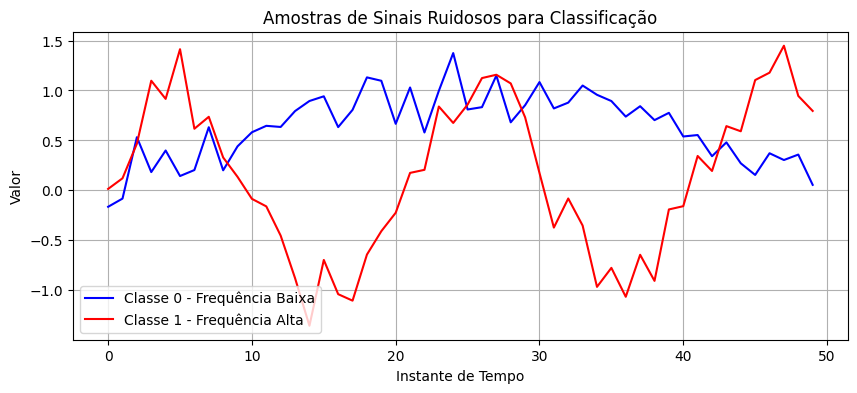

In [ ]:
data, labels = generate_classification_data()
print("Dimensão dos dados:", data.shape)
print("Dimensão das etiquetas:", labels.shape)

# Plotando amostras de cada classe
plt.figure(figsize=(10, 4))
idx_class_0 = np.where(labels == 0)[0][0]
idx_class_1 = np.where(labels == 1)[0][0]

plt.plot(data[idx_class_0, :, 0], label="Classe 0 - Frequência Baixa", color="blue")
plt.plot(data[idx_class_1, :, 0], label="Classe 1 - Frequência Alta", color="red")
plt.title("Amostras de Sinais Ruidosos para Classificação")
plt.xlabel("Instante de Tempo")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.show()

### Dataset e DataLoader

Criamos uma classe para carregar nossos dados no PyTorch e realizar o particionamento entre conjuntos de treinamento e teste.

In [ ]:
class ClassificationDataset(Dataset):
    def __init__(self, x_data, y_data):
        self.x = torch.tensor(x_data)
        self.y = torch.tensor(y_data)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [ ]:
split = int(0.8 * len(data))
x_train, x_test = data[:split], data[split:]
y_train, y_test = labels[:split], labels[split:]

train_dataset = ClassificationDataset(x_train, y_train)
test_dataset = ClassificationDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### Arquitetura do Classificador

A arquitetura do classificador contém uma camada recorrente nativa seguida por uma camada linear simples que projeta a representação do último passo de tempo em duas classes.

In [ ]:
class RNNClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: [batch_size, sequence_length, input_size]
        out, h_n = self.rnn(x)
        # Último passo de tempo: [batch_size, hidden_size]
        last_out = out[:, -1, :]
        logits = self.fc(last_out)
        return logits

In [ ]:
model = RNNClassifier(input_size=1, hidden_size=8, num_classes=2).to(device)
print(model)

RNNClassifier(
  (rnn): RNN(1, 8, batch_first=True)
  (fc): Linear(in_features=8, out_features=2, bias=True)
)


### Otimização e Treinamento

Definimos o otimizador Adam e a função de perda de entropia cruzada para ajustar os parâmetros do modelo ao longo das épocas de treinamento.

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

Época 01/15 | Perda: 0.6788
Época 02/15 | Perda: 0.6035
Época 03/15 | Perda: 0.4877
Época 04/15 | Perda: 0.2917
Época 05/15 | Perda: 0.1131
Época 06/15 | Perda: 0.0466
Época 07/15 | Perda: 0.0257
Época 08/15 | Perda: 0.0162
Época 09/15 | Perda: 0.0122
Época 10/15 | Perda: 0.0097
Época 11/15 | Perda: 0.0079
Época 12/15 | Perda: 0.0067
Época 13/15 | Perda: 0.0059
Época 14/15 | Perda: 0.0051
Época 15/15 | Perda: 0.0045


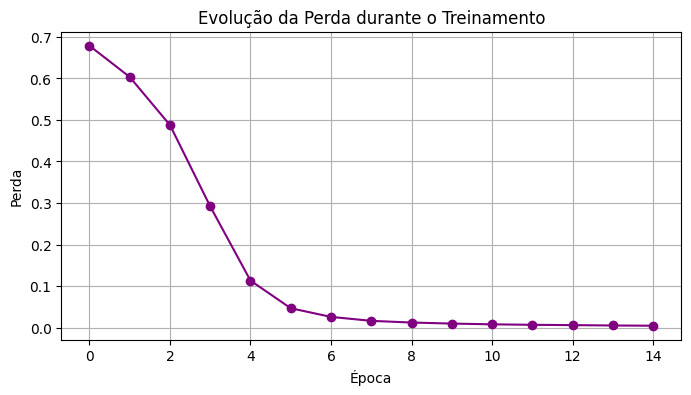

In [ ]:
epochs = 15
losses = []

model.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Época {epoch+1:02d}/{epochs} | Perda: {avg_loss:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(losses, color="purple", marker="o")
plt.title("Evolução da Perda durante o Treinamento")
plt.xlabel("Época")
plt.ylabel("Perda")
plt.grid(True)
plt.show()

### Visualização de Resultados

Avaliamos o modelo em dados de teste inéditos para verificar a qualidade das classificações obtidas por meio de predições visuais.

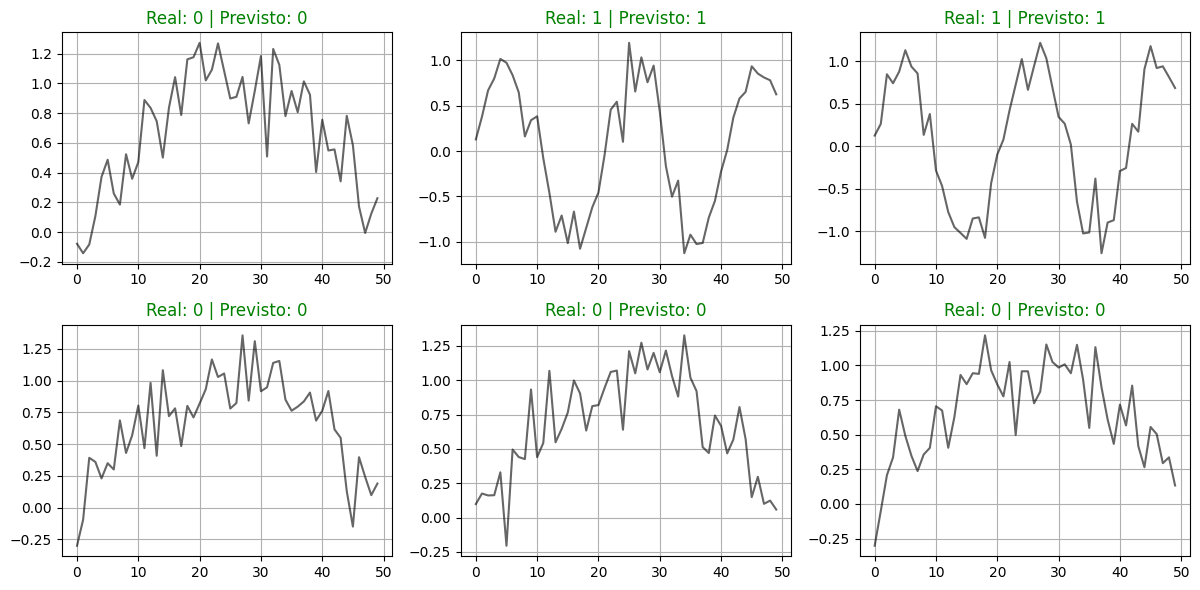

In [ ]:
model.eval()
test_x, test_y = next(iter(test_loader))

with torch.no_grad():
    test_x = test_x.to(device)
    logits = model(test_x)
    predictions = torch.argmax(logits, dim=1).cpu().numpy()

test_x = test_x.cpu().numpy()
test_y = test_y.numpy()

plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    is_correct = predictions[i] == test_y[i]
    color = "green" if is_correct else "red"

    plt.plot(test_x[i, :, 0], color="black", alpha=0.6)
    plt.title(f"Real: {test_y[i]} | Previsto: {predictions[i]}", color=color)
    plt.grid(True)

plt.tight_layout()
plt.show()

## Predição de Séries Temporais

Agora criamos um modelo recorrente para prever o próximo valor de uma série temporal contínua com base em uma janela de observações passadas.

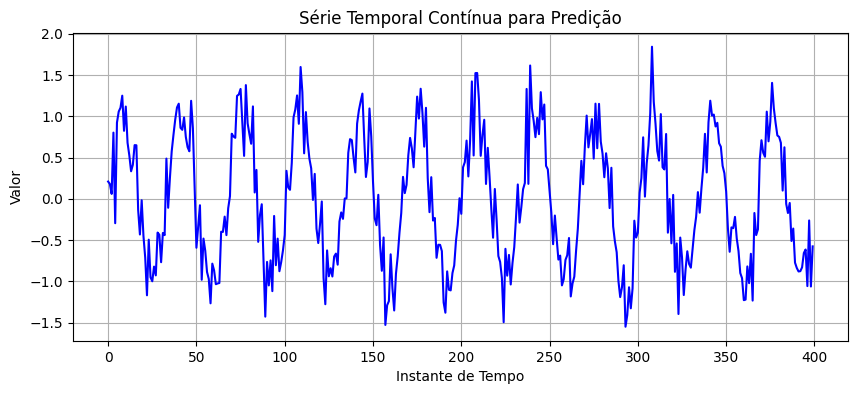

In [ ]:
# Geração da série temporal contínua com maior frequência e ruído gaussiano
t = np.linspace(0, 50, 400)
series = np.sin(1.5 * t) + np.random.normal(0, 0.3, len(t))

plt.figure(figsize=(10, 4))
plt.plot(series, color="blue")
plt.title("Série Temporal Contínua para Predição")
plt.xlabel("Instante de Tempo")
plt.ylabel("Valor")
plt.grid(True)
plt.show()

### Preparação do Dataset de Janelas Deslizantes

Montamos as janelas temporais de tamanho fixo onde a entrada é uma sequência curta e o alvo de treinamento representa o elemento imediatamente seguinte.

In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data_series, window_size=20):
        self.data = torch.tensor(data_series, dtype=torch.float32)
        self.window_size = window_size

    def __len__(self):
        return len(self.data) - self.window_size

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.window_size].unsqueeze(-1)
        y = self.data[idx + self.window_size].unsqueeze(-1)
        return x, y

In [ ]:
split_index = 300
train_series = series[:split_index]
test_series = series[split_index:]

window_size = 10
train_predict_dataset = TimeSeriesDataset(train_series, window_size)
test_predict_dataset = TimeSeriesDataset(test_series, window_size)

train_predict_loader = DataLoader(train_predict_dataset, batch_size=16, shuffle=True)
test_predict_loader = DataLoader(test_predict_dataset, batch_size=1, shuffle=False)

### Arquitetura do Preditor

A arquitetura do preditor utiliza a camada recorrente nativa para codificar a janela temporal em um estado latente e uma camada linear que estima o próximo valor escalar contínuo.

In [ ]:
class RNNPredictor(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: [batch_size, window_size, input_size]
        out, h_n = self.rnn(x)
        last_out = out[:, -1, :]
        prediction = self.fc(last_out)
        return prediction

In [ ]:
predictor_model = RNNPredictor(input_size=1, hidden_size=16).to(device)
print(predictor_model)

RNNPredictor(
  (rnn): RNN(1, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)


### Otimização e Treinamento do Preditor

Utilizamos o otimizador Adam e a função de perda do erro quadrático médio para o treinamento do preditor.

In [ ]:
criterion_mse = nn.MSELoss()
optimizer_predictor = optim.Adam(predictor_model.parameters(), lr=0.005)

Época 01/100 | MSE Loss: 0.478144
Época 02/100 | MSE Loss: 0.203417
Época 03/100 | MSE Loss: 0.146996
Época 04/100 | MSE Loss: 0.125893
Época 05/100 | MSE Loss: 0.119305
Época 06/100 | MSE Loss: 0.121483
Época 07/100 | MSE Loss: 0.108489
Época 08/100 | MSE Loss: 0.114622
Época 09/100 | MSE Loss: 0.125167
Época 10/100 | MSE Loss: 0.109758
Época 11/100 | MSE Loss: 0.109153
Época 12/100 | MSE Loss: 0.105451
Época 13/100 | MSE Loss: 0.102959
Época 14/100 | MSE Loss: 0.105568
Época 15/100 | MSE Loss: 0.110455
Época 16/100 | MSE Loss: 0.106223
Época 17/100 | MSE Loss: 0.111608
Época 18/100 | MSE Loss: 0.108689
Época 19/100 | MSE Loss: 0.119129
Época 20/100 | MSE Loss: 0.105402
Época 21/100 | MSE Loss: 0.108462
Época 22/100 | MSE Loss: 0.121107
Época 23/100 | MSE Loss: 0.104569
Época 24/100 | MSE Loss: 0.106543
Época 25/100 | MSE Loss: 0.105503
Época 26/100 | MSE Loss: 0.102232
Época 27/100 | MSE Loss: 0.121727
Época 28/100 | MSE Loss: 0.104133
Época 29/100 | MSE Loss: 0.101504
Época 30/100 |

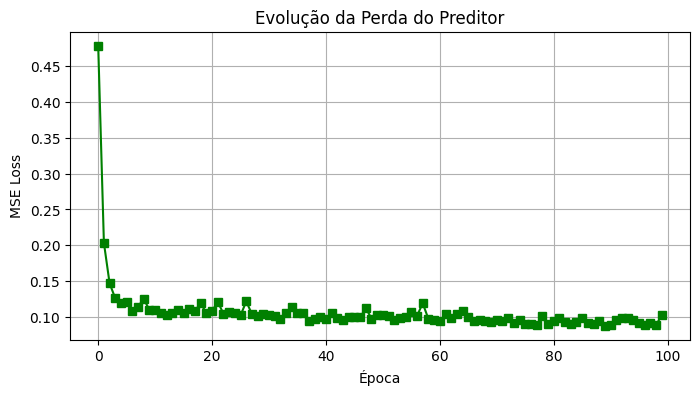

In [ ]:
predict_epochs = 100
predict_losses = []

predictor_model.train()
for epoch in range(predict_epochs):
    epoch_loss = 0.0
    for batch_x, batch_y in train_predict_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        predictions = predictor_model(batch_x)
        loss = criterion_mse(predictions, batch_y)

        optimizer_predictor.zero_grad()
        loss.backward()
        # Estabilização dos gradientes por meio de corte de norma
        nn.utils.clip_grad_norm_(predictor_model.parameters(), max_norm=1.0)
        optimizer_predictor.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_predict_loader)
    predict_losses.append(avg_loss)
    print(f"Época {epoch+1:02d}/{predict_epochs} | MSE Loss: {avg_loss:.6f}")

plt.figure(figsize=(8, 4))
plt.plot(predict_losses, color="green", marker="s")
plt.title("Evolução da Perda do Preditor")
plt.xlabel("Época")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

### Avaliação e Geração Autoregressiva

Avaliamos a capacidade de predição gerando os pontos futuros de forma autoregressiva. Alimentamos o modelo com a primeira janela de teste. Ele estima o primeiro ponto futuro. Em seguida, removemos o ponto mais antigo dessa janela e adicionamos a predição obtida para realizar a estimativa do passo seguinte, repetindo o ciclo recursivamente.

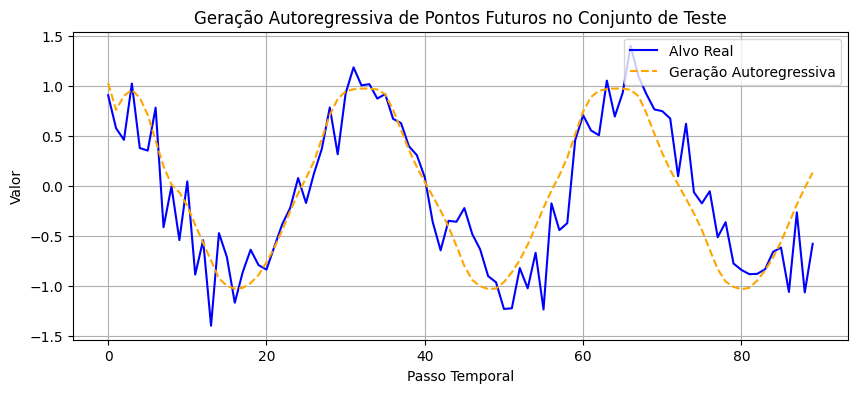

In [ ]:
predictor_model.eval()
autoregressive_predictions = []
true_targets = []

# Inicializamos a janela deslizante com a primeira janela do conjunto de teste
current_window = torch.tensor(test_series[:window_size], dtype=torch.float32).unsqueeze(-1).to(device)

# Geramos os pontos seguintes de forma recursiva
steps_to_predict = len(test_series) - window_size

with torch.no_grad():
    for i in range(steps_to_predict):
        # Formato de entrada esperado com dimensão de lote: [1, window_size, 1]
        x_input = current_window.unsqueeze(0)
        pred = predictor_model(x_input)

        pred_val = pred.item()
        autoregressive_predictions.append(pred_val)
        true_targets.append(test_series[window_size + i])

        # Atualizamos a janela: removemos o primeiro elemento e adicionamos a nova predição ao final
        new_point = torch.tensor([[pred_val]], dtype=torch.float32).to(device)
        current_window = torch.cat([current_window[1:], new_point], dim=0)

# Plotando os resultados comparativos de geração autoregressiva
plt.figure(figsize=(10, 4))
plt.plot(true_targets, label="Alvo Real", color="blue")
plt.plot(autoregressive_predictions, label="Geração Autoregressiva", color="orange", linestyle="--")
plt.title("Geração Autoregressiva de Pontos Futuros no Conjunto de Teste")
plt.xlabel("Passo Temporal")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.show()

## Exercícios

### Exercício 1: Estado oculto

Altere o tamanho do estado oculto do preditor para 4 e para 64. Treine o modelo nas mesmas condições e compare o resultado visual das predições para cada caso.

### Exercício 2: Ruído

Aumente a quantidade de ruído na geração do conjunto de dados de classificação. Execute o treinamento novamente e analise como a taxa de acerto do classificador reage ao aumento de ruído nos sinais.

Treinando modelo com hidden_dim = 4...
Treinando modelo com hidden_dim = 64...


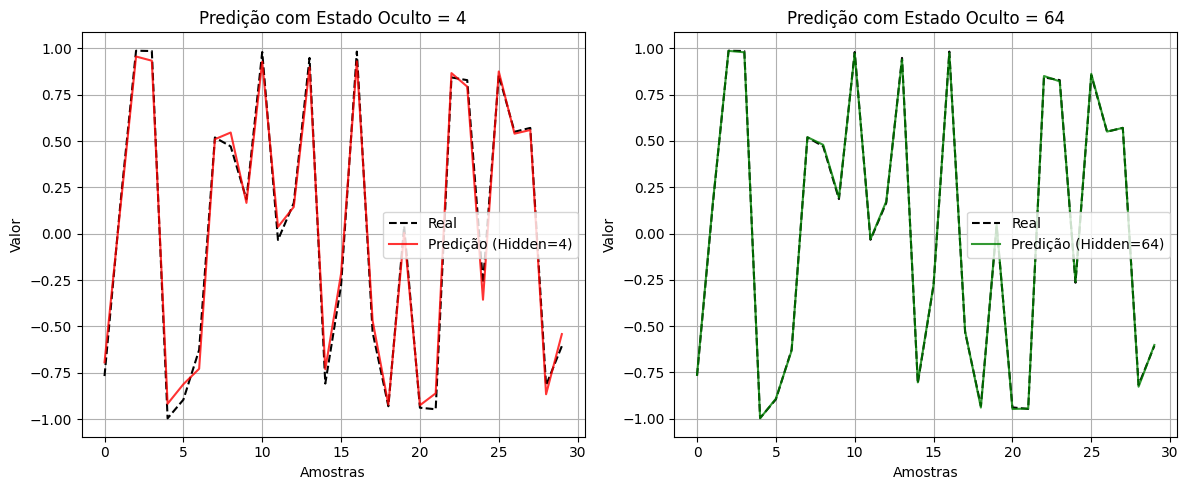

In [ ]:
import math
import random
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# CONFIGURAÇÕES DE SEMENTE E DISPOSITIVO
random.seed(42)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ==========================================
# 1. GERAÇÃO DE DADOS (ONDA SENOIDAL)
# ==========================================
def gerar_dados_seno(seq_len=50, num_amostras=100):
    X = []
    Y = []
    for _ in range(num_amostras):
        start = random.uniform(0, 2 * math.pi)
        # Cria uma sequência de pontos no tempo
        tempo = torch.linspace(start, start + 2 * math.pi, seq_len + 1)
        seno = torch.sin(tempo)

        # X: pontos de 0 a seq_len-1 | Y: ponto seq_len (próximo valor a prever)
        X.append(seno[:-1].unsqueeze(-1))  # Shape: [seq_len, 1]
        Y.append(seno[-1].unsqueeze(-1))  # Shape: [1]

    return torch.stack(X), torch.stack(Y)


X_train, Y_train = gerar_dados_seno()
X_train, Y_train = X_train.to(device), Y_train.to(device)

# ==========================================
# 2. ARQUITETURA DO PREDITOR (RNN/LSTM)
# ==========================================


class RNNPredictor(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim=1):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # out: [batch_size, seq_len, hidden_dim]
        # hidden: [1, batch_size, hidden_dim]
        out, (hidden, _) = self.lstm(x)
        # Usamos o estado oculto da última etapa de tempo para prever o próximo valor
        return self.fc(out[:, -1, :])


# ==========================================
# 3. FUNÇÃO DE TREINAMENTO E AVALIAÇÃO
# ==========================================
def treinar_e_prever(hidden_dim, num_epochs=100):
    model = RNNPredictor(input_dim=1, hidden_dim=hidden_dim).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    # Loop de Treino rápido
    model.train()
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        predictions = model(X_train)
        loss = criterion(predictions, Y_train)
        loss.backward()
        optimizer.step()

    # Avaliação/Predição
    model.eval()
    with torch.no_grad():
        preds = model(X_train).cpu().numpy()

    return preds


# Executando o experimento para os dois tamanhos de estado oculto
print("Treinando modelo com hidden_dim = 4...")
preds_hidden_4 = treinar_e_prever(hidden_dim=4)

print("Treinando modelo com hidden_dim = 64...")
preds_hidden_64 = treinar_e_prever(hidden_dim=64)

# ==========================================
# 4. PLOTAGEM E COMPARAÇÃO VISUAL
# ==========================================
target_real = Y_train.cpu().numpy()

plt.figure(figsize=(12, 5))

# Subplot 1: Hidden Dim = 4
plt.subplot(1, 2, 1)
plt.plot(target_real[:30], label="Real", color="black", linestyle="--")
plt.plot(
    preds_hidden_4[:30], label="Predição (Hidden=4)", color="red", alpha=0.8
)
plt.title("Predição com Estado Oculto = 4")
plt.xlabel("Amostras")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)

# Subplot 2: Hidden Dim = 64
plt.subplot(1, 2, 2)
plt.plot(target_real[:30], label="Real", color="black", linestyle="--")
plt.plot(
    preds_hidden_64[:30],
    label="Predição (Hidden=64)",
    color="green",
    alpha=0.8,
)
plt.title("Predição com Estado Oculto = 64")
plt.xlabel("Amostras")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

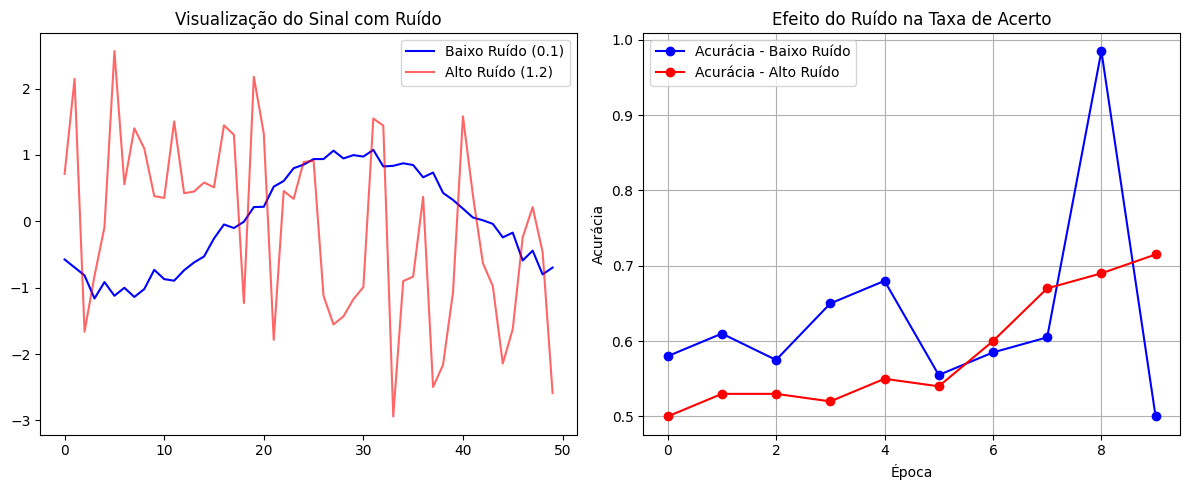

In [ ]:
import math
import random
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# CONFIGURAÇÕES DE SEMENTE E DISPOSITIVO
random.seed(42)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 1. GERADOR DE SINAIS COM CONTROLE DE RUÍDO
# ==========================================
class SignalDataset(Dataset):
    def __init__(self, seq_len=50, num_samples=200, noise_level=0.1):
        self.data = []

        for _ in range(num_samples // 2):
            start = random.uniform(0, 2 * math.pi)
            t = torch.linspace(start, start + 2 * math.pi, seq_len)

            # Classe 0: Onda Senoidal + Ruído Gaussiano
            sine = torch.sin(t) + torch.randn(seq_len) * noise_level
            self.data.append((sine.unsqueeze(-1), 0))

            # Classe 1: Onda Quadrada + Ruído Gaussiano
            square = torch.sign(torch.sin(t)) + torch.randn(seq_len) * noise_level
            self.data.append((square.unsqueeze(-1), 1))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

# ==========================================
# 2. MODELO: CLASSIFICADOR DE SINAIS (RNN)
# ==========================================
class SignalClassifier(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=32, output_dim=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        return self.fc(hidden[-1])

# ==========================================
# 3. FUNÇÃO DE TREINO E AVALIAÇÃO
# ==========================================
def rodar_experimento(noise_level):
    dataset_train = SignalDataset(noise_level=noise_level)
    dataset_val = SignalDataset(noise_level=noise_level)

    train_loader = DataLoader(dataset_train, batch_size=16, shuffle=True)
    val_loader = DataLoader(dataset_val, batch_size=16, shuffle=False)

    model = SignalClassifier().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.005)

    acc_historico = []

    # Loop de treino rápido (10 épocas são suficientes para este teste)
    for epoch in range(10):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

        # Validação
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                preds = outputs.argmax(dim=-1)
                correct += (preds == y).sum().item()
                total += y.size(0)

        acc_historico.append(correct / total)

    return acc_historico, dataset_train[0][0].numpy()

# Executando para Baixo Ruído (0.1) vs Alto Ruído (1.2)
acc_baixo, sinal_limpo = rodar_experimento(noise_level=0.1)
acc_alto, sinal_ruidoso = rodar_experimento(noise_level=1.2)

# ==========================================
# 4. PLOTAGEM DOS RESULTADOS
# ==========================================
plt.figure(figsize=(12, 5))

# Subplot 1: Visualização do Impacto do Ruído no Sinal
plt.subplot(1, 2, 1)
plt.plot(sinal_limpo, label="Baixo Ruído (0.1)", color="blue")
plt.plot(sinal_ruidoso, label="Alto Ruído (1.2)", color="red", alpha=0.6)
plt.title("Visualização do Sinal com Ruído")
plt.legend()

# Subplot 2: Comparação da Acurácia
plt.subplot(1, 2, 2)
plt.plot(acc_baixo, label="Acurácia - Baixo Ruído", color="blue", marker='o')
plt.plot(acc_alto, label="Acurácia - Alto Ruído", color="red", marker='o')
plt.title("Efeito do Ruído na Taxa de Acerto")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()